## Full Fine-Tuning(전체 미세조정)

파인튜닝이 필요한 이유
- LLM은 AI에이전트의 품질을 결정짓는 핵심 요소이다. 
- 큰 모델(클라우드) vs 나의 목적에 특화된 작은 모델 여러개(로컬)
- 사전 훈련은 비용 부담이 크지만 미세조정은 누구나 해볼만 함
- RAG 성능에도 영향을 줌 

pretraining 한 모델을 바탕으로 특정 작업을 더 잘 수행할 수 있도록 추가로 훈련시키는 과정을 파인튜닝이라고 함.<br>
<br>
LLM을 훈련시킬 때는 GPU사용료가 큰 부담이지만, 파인튜닝으로 적은 비용으로 특화 모델을 만들 수 있음. 

---


### 모델 준비 -> 카카오 나노 2.1b base 모델 사용 


| 구분 | Base (기본) | Instruct (지시형) | Embedding (임베딩) |
|:---|:---|:---|:---|
| **HuggingFace** | kakaocorp/kanana-nano-2.1b-base | kakaocorp/kanana-nano-2.1b-instruct | kakaocorp/kanana-nano-2.1b-embedding |
| **핵심 역할** | 대규모 데이터 사전 학습 (지식 습득) | 대화 및 사용자 지시이행 (비서 역할) | 문장의 의미를 숫자(Vector)로 변환 |
| **학습 단계** | Pre-training: 다음 단어 예측 학습 | SFT/RLHF: 대화체 및논리 학습 | Contrastive Learning: 의미 유사도 학습 |
| **특징** | 지식은 많으나 대화 기술이 부족함 | 사람의 질문에 친절하고 정확하게 답변 | 생성 기능이 없으며 의미적 검색에 특화 |
| **추천 상황** | 특정 도메인(법률, 의료 등) 추가 학습 시 | 챗봇, 요약, 일반 질의응답 구현 시 | RAG(문서 검색), 추천 시스템 구축 시 |

In [1]:
import torch

if torch.backends.mps.is_available():
    device = torch.device("mps")
    print("MPS가속을 사용합니다.")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")
    print("GPU를 찾을 수 없어 CPU를 사용합니다.")

MPS가속을 사용합니다.


In [2]:
from transformers import AutoModelForCausalLM, AutoTokenizer

model_name = "kakaocorp/kanana-nano-2.1b-base"
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    torch_dtype = torch.bfloat16,
    trust_remote_code = True,
).to(device)
tokenizer = AutoTokenizer.from_pretrained(model_name, padding_side="left")
tokenizer.pad_token = tokenizer.eos_token 


config.json:   0%|          | 0.00/692 [00:00<?, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


model.safetensors:   0%|          | 0.00/4.17G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/444 [00:00<?, ?B/s]

#### padding_side 를 left로 하는 이유 
모델이 **"사과가 맛있"**이라는 입력을 받고 **"다"**를 예측해야 하는 상황이라고 가정 

1. Right Padding (오른쪽 패딩)<br><br>
대부분의 일반적인 딥러닝 모델이 사용하는 방식<br><br>

- 구조: [사과, 가, 맛있, <|eos|>, <|eos|>] <br><br>
- 문제점: 모델은 항상 마지막 토큰을 보고 다음 단어를 예측하려고 합니다. 그런데 마지막에 있는 것이 실제 단어(맛있)가 아니라 의미 없는 패딩(128001)입니다.<br><br>
- 결과: 모델 입장에서 "맛있" 다음에 뭐가 올지 계산해야 하는데, 중간에 패딩이 끼어 있어 연산 흐름이 끊기거나 예측 성능이 떨어질 수 있습니다.<br><br>

2. Left Padding (왼쪽 패딩)<br><br>
생성형 LLM(Causal LM)에서 Batch(묶음) 추론을 할 때 권장되는 방식<br><br>

- 구조: [<|eos|>, <|eos|>, 사과, 가, 맛있]<br><br>
- 장점: 모델이 읽는 마지막 지점이 항상 실제 단어인 **맛있**으로 끝납니다.<br><br>
- 결과: 모델은 앞에 패딩이 있든 없든, 마지막에 읽은 맛있 다음에 올 다를 아주 자연스럽게 예측할 수 있습니다.

#### 데이터셋 준비 

In [3]:
# qna[0] -> 질문 , qna[1] -> 답 
qna_list = []
with open("jmcustomdata.txt", "r") as file:
    for line in file:
        qna = line.strip().split('|') # 입력 문서의 '|'는 질문과 답변을 구분하는 문자 
        input_str = qna[0] + " " + qna[1]
        item = {'q':qna[0], 'input':input_str, 'q_ids':tokenizer.encode(qna[0]),'input_ids':tokenizer.encode(input_str)}
        qna_list.append(item)

max_lenguth = max(len(item['input_ids']) for item in qna_list)

print(qna_list)
print(max_lenguth)


[{'q': '다음 숫자들을 얘기해봐 54321', 'input': '다음 숫자들을 얘기해봐 54321 98765.', 'q_ids': [128000, 13447, 49531, 70292, 93287, 105880, 123715, 21121, 34983, 122722, 220, 19642, 1691], 'input_ids': [128000, 13447, 49531, 70292, 93287, 105880, 123715, 21121, 34983, 122722, 220, 19642, 1691, 220, 22207, 2397, 13]}, {'q': '가장 좋아하는 과일은 무엇인가요?', 'input': '가장 좋아하는 과일은 무엇인가요? 저는 신선하고 달콤한 망고를 가장 좋아합니다.', 'q_ids': [128000, 20565, 41953, 117004, 44005, 104219, 33177, 34804, 118947, 115372, 36811, 30], 'input_ids': [128000, 20565, 41953, 117004, 44005, 104219, 33177, 34804, 118947, 115372, 36811, 30, 102678, 16969, 101327, 101151, 101360, 104685, 100966, 97, 24486, 118974, 35495, 18918, 107120, 117004, 61938, 13]}, {'q': '최근에 즐겨 하는 게임이 있나요?', 'input': '최근에 즐겨 하는 게임이 있나요? 요즘은 전략 시뮬레이션 게임인 시티즈 스카이라인 2를 즐겨 합니다.', 'q_ids': [128000, 104156, 104152, 19954, 118598, 108381, 105365, 108573, 13094, 36439, 114067, 30], 'input_ids': [128000, 104156, 104152, 19954, 118598, 108381, 105365, 108573, 13094, 36439, 114067, 30, 8

In [4]:
# 파인튜닝 전에 어떻게 응답하는지 확인 
questions = [ qna['q'] for qna in qna_list]
questions.append("너에 대해서 설명해봐.")
questions.append("이처럼 인간처럼 생각하고 행동하는 AI 모델은 ")
questions.append("인공지능의 장점은")
questions.append("카카오 나노 모델에 대해서 얘기해봐.") 

input_ids = tokenizer(
    questions,
    padding=True,
    return_tensors="pt",
)["input_ids"].to(device) 

model.eval()
with torch.no_grad():
    output = model.generate(
        input_ids,
        max_new_tokens=32,
        do_sample=False,
    )

output_list = output.tolist()

for i, output in enumerate(output_list):
    # skip_special_tokens=True를 추가하여 패딩 토큰(128001)이 결과에 섞이지 않게 함 
    print(f"Q{i}: {tokenizer.decode(output, skip_special_tokens=True)}")

The attention mask and the pad token id were not set. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.
Setting `pad_token_id` to `eos_token_id`:128001 for open-end generation.
The attention mask is not set and cannot be inferred from input because pad token is same as eos token. As a consequence, you may observe unexpected behavior. Please pass your input's `attention_mask` to obtain reliable results.


Q0: 다음 숫자들을 얘기해봐 54321 54321 54321 54321 54321 54321 54321 54321 54321 54321 54321 543
Q1: 가장 좋아하는 과일은 무엇인가요? 1. 사과 2. 바나나 3. 딸기 4. 수박 5. 포도 6. 귤 
Q2: 최근에 즐겨 하는 게임이 있나요? 1. 2. 3. 4. 5. 6. 7. 8. 9. 10. 11
Q3: 추천하고 싶은 여행지는 어디인가요? 1. 2. 3. 4. 5. 6. 7. 8. 9. 10. 11
Q4: 평소에 즐기는 취미는 무엇인가요? 1. 독서 2. 운동 3. 영화보기 4. 게임 5. 음악감상 6. 여행 7. 요
Q5: 어떤 계절을 가장 선호하시나요? 1. 봄 2. 여름 3. 가을 4. 겨울 5. 사계절 모두 5. 사계
Q6: 본인만의 특별한 재능이 있나요?  2. 내가 잘하는 것과 좋아하는 것 중에 무엇을 선택해야 할까요?  3. 내가 잘하는 것과 좋아하는
Q7: 자주 듣는 음악 플레이리스트의 장르는? 1. 힙합 2. 발라드 3. 락 4. 팝 5. 클래식 6.
Q8: 가장 좋아하는 색깔은 무엇인가요? 2. 내가 좋아하는 색깔을 이용하여 나만의 캐릭터를 만들어 보세요. 3. 내가 좋아하는 색깔
Q9: 영화관에 가면 주로 어떤 장르를 보나요? 2. 영화관에서 영화를 보는 것과 집에서 영화를 보는 것 중 어느 쪽이 더 좋나요? 3. 영화관
Q10: 건강 관리를 위해 하는 운동이 있나요? 1. 운동을 하면 좋은 점은 무엇인가요? 2. 운동을 하면 어떤 점이 좋나요? 3. 운동을 하면 어떤
Q11: 좋아하는 동물이 있나요? 1. 고양이 2. 강아지 3. 토끼 4. 햄스터 5. 거북이 6.
Q12: 주로 이용하는 디지털 플랫폼은 무엇인가요? 1. 페이스북 2. 인스타그램 3. 유튜브 4. 트위터 5. 카카�
Q13: 가장 좋아하는 한국 음식은 무엇인가요? 1. 김치 2. 불고기 3. 떡볶이 4. 비빔밥 5. 잡채
Q14: 최근에 감명 깊게 본 영상 콘텐츠는? 1. 2. 3. 4. 5. 6. 7. 8

#### 데이터셋을 마스킹해서 전처리하는 과정 

In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

EOT = 128001 
class MyDataset(Dataset):
    def __init__(self, qna_list, max_lenguth):
        self.input_ids = []
        self.target_ids = []
        
        for qa in qna_list:
            token_ids = qa['input_ids']
            input_chunk = token_ids # 모델에게 보여주는 문제
            target_chunk = token_ids[1:] # 모델이 맞혀야 하는 정답
            input_chunk += [EOT]* (max_lenguth - len(input_chunk))
            target_chunk += [EOT]* (max_lenguth - len(target_chunk))
            len_ignore = len(qa['q_ids']) - 1 # target은 한 글자가 짧기 때문
            # 질문에 해당하는 부분(len_ignore)을 -100으로 가림 -> 마스킹 
            target_chunk[:len_ignore] = [-100] * len_ignore 
            
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))
    
    def __len__(self):
        return len(self.input_ids)
    
    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]

dataset = MyDataset(qna_list, max_lenguth=max_lenguth)

train_loader = DataLoader(dataset, batch_size=2, shuffle=True, drop_last=False)


In [6]:
i = iter(train_loader)

In [7]:
x,y = next(i)
y_temp = y[0].tolist()
y_temp = [x for x in y_temp if x != -100] # -100을 제외하고 디코딩 

print(tokenizer.decode(x[0].tolist()))
print(tokenizer.decode(y_temp))

<|begin_of_text|>인생의 목표를 세울 때 가장 먼저 고려할 점은? 자신이 진정으로 가치 있다고 느끼는 것이 무엇인지, 즉 '자기 가치관'을 먼저 파악해야 합니다.<|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|>
 자신이 진정으로 가치 있다고 느끼는 것이 무엇인지, 즉 '자기 가치관'을 먼저 파악해야 합니다.<|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|><|end_of_text|>


#### 훈련 
- 데이터셋이 너무 작아서 validation은 생략함 

In [8]:
import torch

print(device)
torch.manual_seed(123)
model.to(device)
# lr은 원본 학습 파라미터를 회손하지 않기 위해 매우 적게 주었음 
optimizer = torch.optim.AdamW(model.parameters(), lr=0.00001, weight_decay=0.01) 

mps


In [10]:
tokens_seen, global_step = 0, -1

losses = []

for epoch in range(10):
    model.train() # Set model to training mode
    epoch_loss = 0
    for input_batch, target_batch in train_loader:
        optimizer.zero_grad() 
        input_batch, target_batch = input_batch.to(device),target_batch.to(device)

        logits = model(input_batch).logits 
        loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
        epoch_loss += loss.item() 
        loss.backward()
        optimizer.step()
        tokens_seen += input_batch.numel()
        global_step += 1

        print(f"{global_step} Tokens seen: {tokens_seen}")
    avg_loss = epoch_loss / len(train_loader)
    losses.append(avg_loss)
    print(f"Epoch: {epoch}, Loss: {avg_loss}")
    torch.save(model.state_dict(), "model_" + str(epoch).zfill(3) + ".pth")


0 Tokens seen: 122
1 Tokens seen: 244
2 Tokens seen: 366
3 Tokens seen: 488
4 Tokens seen: 610
5 Tokens seen: 732
6 Tokens seen: 854
7 Tokens seen: 976
8 Tokens seen: 1098
9 Tokens seen: 1220
10 Tokens seen: 1342
11 Tokens seen: 1464
12 Tokens seen: 1586
13 Tokens seen: 1708
14 Tokens seen: 1830
15 Tokens seen: 1952
16 Tokens seen: 2074
17 Tokens seen: 2196
18 Tokens seen: 2318
19 Tokens seen: 2440
20 Tokens seen: 2562
21 Tokens seen: 2684
22 Tokens seen: 2806
23 Tokens seen: 2928
24 Tokens seen: 3050
25 Tokens seen: 3172
26 Tokens seen: 3294
27 Tokens seen: 3416
28 Tokens seen: 3538
29 Tokens seen: 3660
30 Tokens seen: 3782
31 Tokens seen: 3904
32 Tokens seen: 4026
33 Tokens seen: 4148
34 Tokens seen: 4270
35 Tokens seen: 4392
36 Tokens seen: 4514
37 Tokens seen: 4636
Epoch: 0, Loss: 1.035875822368421
38 Tokens seen: 4758
39 Tokens seen: 4880
40 Tokens seen: 5002
41 Tokens seen: 5124
42 Tokens seen: 5246
43 Tokens seen: 5368
44 Tokens seen: 5490
45 Tokens seen: 5612
46 Tokens seen: 57

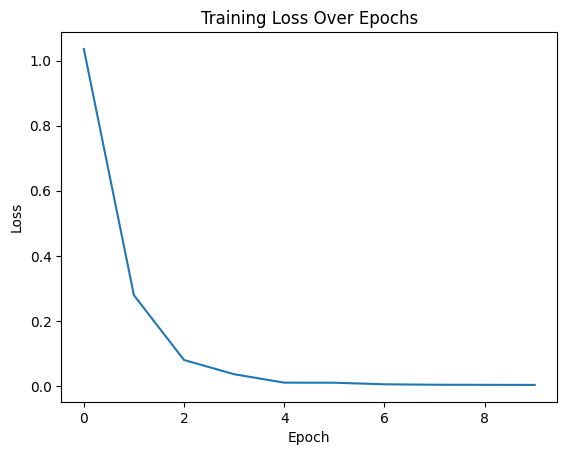

In [11]:
import matplotlib.pyplot as plt
plt.plot(losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs')
plt.show() 

#### 결과 확인

In [12]:
# 파인튜닝 후에 어떻게 응답하는지 확인 
model.load_state_dict(torch.load("model_009.pth", map_location=device, weights_only=True))
model.eval() 

LlamaForCausalLM(
  (model): LlamaModel(
    (embed_tokens): Embedding(128256, 1792)
    (layers): ModuleList(
      (0-31): 32 x LlamaDecoderLayer(
        (self_attn): LlamaAttention(
          (q_proj): Linear(in_features=1792, out_features=3072, bias=False)
          (k_proj): Linear(in_features=1792, out_features=1024, bias=False)
          (v_proj): Linear(in_features=1792, out_features=1024, bias=False)
          (o_proj): Linear(in_features=3072, out_features=1792, bias=False)
        )
        (mlp): LlamaMLP(
          (gate_proj): Linear(in_features=1792, out_features=8064, bias=False)
          (up_proj): Linear(in_features=1792, out_features=8064, bias=False)
          (down_proj): Linear(in_features=8064, out_features=1792, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): LlamaRMSNorm((1792,), eps=1e-05)
        (post_attention_layernorm): LlamaRMSNorm((1792,), eps=1e-05)
      )
    )
    (norm): LlamaRMSNorm((1792,), eps=1e-05)
    (

In [13]:
from torch.cuda import temperature
questions = [qna['q'] for qna in qna_list]
questions.append("54321")
questions.append("가장 좋아하는 과일은 무엇인가요?")
questions.append("가장 좋아하는 프로그래밍 언어는 무엇인가요?")
questions.append("객체 지향 프로그래밍의 4대 특징은 무엇인가요?")
questions.append("인공지능 기술이 우리 삶에 미칠 가장 큰 변화는 무엇일까요?")

for i, q in enumerate(questions):
    input_ids = tokenizer(
        q,
        padding=True,
        return_tensors="pt",
    )["input_ids"].to(device)

    model.eval()
    with torch.no_grad():
        output = model.generate(
            input_ids,
            max_new_tokens=32,
            attention_mask = (input_ids != 0).long(),
            pad_token_id=tokenizer.eos_token_id,
            do_sample=False,
            temperature = 1.2,
            top_k=5
        )
    output_list = output.tolist()
    print(f"Q{i}: {tokenizer.decode(output[0], skip_special_tokens=True)}")

The following generation flags are not valid and may be ignored: ['temperature', 'top_k']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Q0: 다음 숫자들을 얘기해봐 54321 98765.
Q1: 가장 좋아하는 과일은 무엇인가요? 저는 신선하고 달콤한 망고를 가장 좋아합니다.
Q2: 최근에 즐겨 하는 게임이 있나요? 요즘은 전략 시뮬레이션 게임인 시티즈 스카이라인 2를 즐겨 합니다.
Q3: 추천하고 싶은 여행지는 어디인가요? 조용하게 산책하며 사색을 즐길 수 있는 제주도의 숲길을 추천합니다.
Q4: 평소에 즐기는 취미는 무엇인가요? 주말마다 새로운 요리 레시피를 시도해보는 것이 제 취미입니다.
Q5: 어떤 계절을 가장 선호하시나요? 나들이 가기 좋은 날씨와 선선한 바람이 부는 가을을 가장 선호합니다.
Q6: 본인만의 특별한 재능이 있나요? 복잡한 정보를 이해하기 쉽게 요약해서 설명하는 것에 자신이 있습니다.
Q7: 자주 듣는 음악 플레이리스트의 장르는? 집중력을 높여주는 잔잔한 로파이(Lo-Fi) 비트를 주로 듣습니다.
Q8: 가장 좋아하는 색깔은 무엇인가요? 마음을 차분하게 만들어주는 깊은 바다색인 네이비 블루를 좋아합니다.
Q9: 영화관에 가면 주로 어떤 장르를 보나요? 스릴 넘치는 추리물이나 반전이 있는 미스터리 영화를 선호합니다.
Q10: 건강 관리를 위해 하는 운동이 있나요? 매일 아침 스트레칭과 가벼운 요가로 하루를 시작합니다.
Q11: 좋아하는 동물이 있나요? 귀엽고 영리한 리트리버 강아지를 아주 좋아합니다.
Q12: 주로 이용하는 디지털 플랫폼은 무엇인가요? 최신 기술 트렌드를 파악하기 위해 주로 레딧(Reddit)과 엑스(X)를 이용합니다.
Q13: 가장 좋아하는 한국 음식은 무엇인가요? 매콤달콤한 양념이 잘 밴 떡볶이를 가장 좋아합니다.
Q14: 최근에 감명 깊게 본 영상 콘텐츠는? 최근에 공개된 우주 다큐멘터리 시리즈를 감명 깊게 봤습니다.
Q15: 어떤 종류의 콘텐츠를 멀리하시나요? 자극적이기만 하고 내용이 없는 가짜 뉴스와 자극적인 영상을 멀리합니다.
Q16: 가장 좋아하는 프로그래밍 언어는 무엇인가요? 저는 시스템의 안정성과 성능을 동시에 챙길 수 있는 Rust를 가장

In [14]:
input_ids = tokenizer(
    input(),
    padding=True,
    return_tensors="pt"
)["input_ids"].to(device)

model.eval()
with torch.no_grad():
    output = model.generate(
        input_ids,
        max_new_tokens=32,
        attention_mask = (input_ids != 0).long(),
        pad_token_id=tokenizer.eos_token_id,
        do_sample=False,
        temperature=1.5,
        top_k=5
    )

output_list = output.tolist()

print(f"Q{i}: {tokenizer.decode(output[0], skip_special_tokens=True)}")

Q80: 인공지능 기술이 삶에 미칠 변화는 상상 이상입니다. 자율 주행 자동차가 일상화되고, AI 비서가 우리의 일상을 더욱 편리하게 만들어줄 것입니다
